
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal

In [26]:
# Parámetros de la malla (Unidades Atómicas)

rmin = 1e-6         # Se evita r = 0 para no dividir por cero
rmax = 20.0         # Dominio espacial suficiente (20 radios de Bohr)
N = 1000            # Número de puntos discretos (Dimensión de la matriz/número de energias a calcular)
r = np.linspace(rmin, rmax, N)
dr = r[1] - r[0]

In [29]:
# Construcción de la matriz Hamiltoniana Tridiagonal (H u = E u)

# Diagonal principal: 1 / dr^2 + V(r) y Diagonales secundarias superior e inferior: -1 / (2 * dr^2)

diag_principal = (1.0 / (dr**2)) - (1.0 / r)
diag_off = -0.5 / (dr**2) * np.ones(N - 1)

# Resolución el problema de autovalores

energeticos, autovectores = eigh_tridiagonal(diag_principal, diag_off)

# Convertir autovalores a eV (1 Hartree ≈ 27.21138 eV)

Hartree_to_eV = 27.21138
energeticos_eV = energeticos * Hartree_to_eV

# Resultados numéricos

print("--- PRIMEROS NIVELES DE ENERGÍA CALCULADOS ---")
print(f"Estado fundamental (n=1): {energeticos_eV[1]:.4f} eV  (Teórico: -13.6057 eV)")
print(f"Primer estado excitado (n=2): {energeticos_eV[2]:.4f} eV  (Teórico: -3.4014 eV)")
print(f"Segundo estado excitado (n=3): {energeticos_eV[3]:.4f} eV  (Teórico: -1.5117 eV)")
print(f"Tercer estado excitado (n=4): {energeticos_eV[4]:.4f} eV  (Teórico: -0.8503 eV)")

--- PRIMEROS NIVELES DE ENERGÍA CALCULADOS ---
Estado fundamental (n=1): -13.6030 eV  (Teórico: -13.6057 eV)
Primer estado excitado (n=2): -3.4008 eV  (Teórico: -3.4014 eV)
Segundo estado excitado (n=3): -1.3593 eV  (Teórico: -1.5117 eV)
Tercer estado excitado (n=4): 0.4498 eV  (Teórico: -0.8503 eV)


/tmp/ipykernel_1398/1204027822.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norma = np.trapz(u_n**2, r)


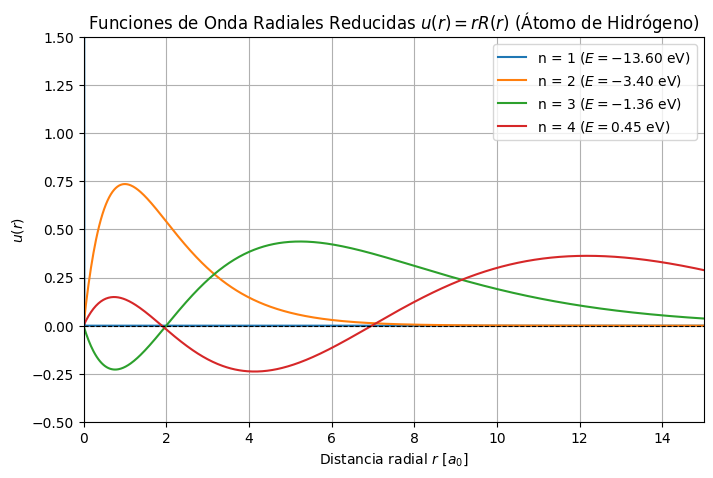

In [31]:
# Visualización de las funciones de onda u(r)

plt.figure(figsize=(8, 5))

for n in range(4):
    # Extraer la función reducida u_n(r) y normalizar

    u_n = autovectores[:, n]

    # Invertir el signo si el primer pico es negativo para gráfica estándar

    if u_n[np.argmax(np.abs(u_n))] < 0:
        u_n = -u_n

    norma = np.trapz(u_n**2, r)
    u_n = u_n / np.sqrt(norma)

    plt.plot(r, u_n, label=f'n = {n+1} ($E = {energeticos_eV[n+1]:.2f}$ eV)')

plt.title('Funciones de Onda Radiales Reducidas $u(r) = r R(r)$ (Átomo de Hidrógeno)')
plt.xlabel('Distancia radial $r$ [$a_0$]')
plt.ylabel('$u(r)$')
plt.xlim(0, 15)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.grid(True)
plt.show()